<a href="https://colab.research.google.com/github/rbarkerclarke/HARTDA/blob/main/SeedFigures_TDAHAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from backcall import callback_prototype
from numpy.random import shuffle
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, Bidirectional
from tensorflow.keras.layers import GlobalAveragePooling1D, MaxPool1D, Reshape, Conv2D, MaxPool2D
from tensorflow.keras.layers import BatchNormalization, AvgPool1D, Flatten, GRU, GlobalAveragePooling2D
from tensorflow.keras.regularizers import L2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
import tarfile
import datetime
import logging

Class Balance by Seed for WISDM-HARB data

In [ ]:
users_18 = np.load("/content/drive/MyDrive/WISDM_Data/users.npy")
y_18 = np.load('/content/drive/MyDrive/WISDM_Data/y.npy')


In [ ]:
import numpy as np
import pandas as pd # Import pandas
from sklearn.model_selection import train_test_split

seeds1 = [5099, 17442, 1336, 91021]
seeds2 = [2671, 89172, 23619, 5667, 120, 214, 9899]
rng = np.random.default_rng(1)
random_seeds = [int(i) for i in list(rng.integers(low=1,high=100000, size=4))]

print(seeds1 + seeds2 + random_seeds)
participants = np.unique(users_18)
j=1
for i in seeds1+seeds2+random_seeds:

  train_seq, test_seq = train_test_split(participants, test_size=0.18, random_state=i)
  #print(test_seq)

  # check class balance for each partition of wisdm_data
  # Use np.isin and convert to pandas Series for value_counts()
  train_labels = pd.Series(y_18[np.isin(users_18, train_seq)])
  test_labels = pd.Series(y_18[np.isin(users_18, test_seq)])

  class_balance_train = train_labels.value_counts()/sum(train_labels.value_counts())
  class_balance_test = test_labels.value_counts()/sum(test_labels.value_counts())
  #print(class_balance_train)
  #print(list(round(class_balance_train,3)))
  #print(list(round(class_balance_test,3)))

  # calculate entropy of class balance
  entropy_train = -np.sum(class_balance_train * np.log2(class_balance_train))
  entropy_test = -np.sum(class_balance_test * np.log2(class_balance_test))
  #print(round(entropy_train,2))
  print(j,'&',i,'&', test_seq,'&',  round(entropy_train, 4),'&',  round(entropy_test,4),'&',  round(entropy_train-entropy_test,4), r'\\' )
  j+=1


[5099, 17442, 1336, 91021, 2671, 89172, 23619, 5667, 120, 214, 9899, 47319, 51182, 75516, 95046]
1 & 5099 & ['1637' '1633' '1623' '1629' '1638' '1641' '1625' '1612' '1642' '1644'] & 4.1694 & 4.1665 & 0.0029 \\
2 & 17442 & ['1640' '1629' '1633' '1610' '1625' '1611' '1631' '1604' '1608' '1620'] & 4.1692 & 4.1685 & 0.0007 \\
3 & 1336 & ['1607' '1645' '1616' '1637' '1643' '1605' '1604' '1644' '1630' '1620'] & 4.1693 & 4.168 & 0.0013 \\
4 & 91021 & ['1605' '1649' '1613' '1636' '1634' '1622' '1607' '1625' '1633' '1606'] & 4.1691 & 4.1698 & -0.0007 \\
5 & 2671 & ['1602' '1629' '1628' '1609' '1606' '1625' '1631' '1612' '1643' '1635'] & 4.1693 & 4.1687 & 0.0006 \\
6 & 89172 & ['1609' '1612' '1648' '1625' '1646' '1638' '1637' '1611' '1644' '1640'] & 4.1694 & 4.1653 & 0.0041 \\
7 & 23619 & ['1622' '1629' '1613' '1610' '1617' '1646' '1612' '1619' '1600' '1635'] & 4.1691 & 4.1698 & -0.0006 \\
8 & 5667 & ['1630' '1648' '1646' '1641' '1635' '1609' '1634' '1629' '1610' '1625'] & 4.1692 & 4.1695 & -0.0

Class balance by Seed for WISDM6 Data

In [ ]:


# Disable logging for training
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# Enable XLA GPU optimizations
tf.config.optimizer.set_jit(True)

# Mixed precision (if GPU supports it)
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# Connect drive
from google.colab import drive
drive.mount('/content/drive')

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s')
logger = logging.getLogger()

# Suppress TensorFlow GPU warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Enable memory growth for the GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        logger.error(f"GPU error: {e}")

logger.info("Starting data preprocessing...")
print("Starting data preprocessing...")

# Define the path to the main dataset file
data_file = os.path.join('/content/drive/MyDrive/','WISDM_Data/WISDM_ar_v1.1_raw_clean.csv')


# Load the dataset, skipping bad lines
logger.info("Loading dataset...")
column_names = ['user', 'activity', 'timestamp', 'x', 'y', 'z']
wisdm_data = pd.read_csv(data_file, header=0, on_bad_lines="warn")
#wisdm_data = df_final
print(f"Initial dataset shape: {wisdm_data.shape}")

# Data Cleaning
# Convert all values to strings
wisdm_data['x'] = wisdm_data['x'].astype(str)
wisdm_data['y'] = wisdm_data['y'].astype(str)
wisdm_data['z'] = wisdm_data['z'].astype(str)

# Remove non-numeric characters
wisdm_data['x'] = wisdm_data['x'].str.replace(';', '', regex=False)
wisdm_data['y'] = wisdm_data['y'].str.replace(';', '', regex=False)
wisdm_data['z'] = wisdm_data['z'].str.replace(';', '', regex=False)

# Linear interpolation of missing x, y z values
wisdm_data['x'] = wisdm_data['x'].astype(float)
wisdm_data['y']= wisdm_data['y'].astype(float)
wisdm_data['z'] = wisdm_data['z'].astype(float)

# Convert columns back to numeric
wisdm_data['x'] = pd.to_numeric(wisdm_data['x'])
wisdm_data['y'] = pd.to_numeric(wisdm_data['y'])
wisdm_data['z'] = pd.to_numeric(wisdm_data['z'])

# Handle missing values
print(wisdm_data.shape)
wisdm_data = wisdm_data.dropna()
print(wisdm_data.shape)

logger.info(f"Dataset shape after cleaning: {wisdm_data.shape}")


# Calculate magnitude
#wisdm_data['magnitude'] = np.sqrt(wisdm_data['x']**2 + wisdm_data['y']**2 + wisdm_data['z']**2)

# Handle NaN and infinite values
wisdm_data = wisdm_data.replace([np.inf, -np.inf], np.nan).fillna(method='ffill').fillna(method='bfill')

# Map activity labels to integers
activity_mapping = {label: idx for idx, label in enumerate(wisdm_data['activity'].unique())}
wisdm_data['activity'] = wisdm_data['activity'].map(activity_mapping)

# Reverse mapping for later use
reverse_activity_mapping = {v: k for k, v in activity_mapping.items()}

# Normalize features
logger.info("Normalizing features...")
scaler = StandardScaler()
features = ['x', 'y', 'z']
wisdm_data[features] = scaler.fit_transform(wisdm_data[features])
subset_columns = ['x', 'y', 'z', 'user', 'activity']
wisdm_data = wisdm_data[subset_columns]
# Create sequences
stepratio = 0.5
def create_sequences(data, seq_length, ratio=stepratio):
    step=round(seq_length*ratio)
    sequences = []
    labels = []
    users = []
    for start in range(0, len(data) - seq_length, step):
        sequences.append(data.iloc[start:start + seq_length][features].values)
        labels.append(data.iloc[start + seq_length - 1]['activity'])
        users.append(data.iloc[start + seq_length - 1]['user'])
    return np.array(sequences), np.array(labels), np.array(users)

# Create sequences from the data
sequence_length = 128

# Split the data by participants first
#logger.info("Splitting the data by participants...")
participants = wisdm_data['user'].unique()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Starting data preprocessing...
Initial dataset shape: (1030386, 6)
(1030386, 6)
(1030386, 6)


/tmp/ipython-input-3631991765.py:103: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wisdm_data = wisdm_data.replace([np.inf, -np.inf], np.nan).fillna(method='ffill').fillna(method='bfill')


In [ ]:
import numpy as np
seeds1 = [5099, 17442, 1336, 91021]
seeds2 = [2671, 89172, 23619, 5667, 120, 214, 9899]
rng = np.random.default_rng(1)
random_seeds = [int(i) for i in list(rng.integers(low=1,high=100000, size=4))]

print(seeds1 + seeds2 + random_seeds)

# create sequence 1:36
sequence = list(range(1,37))
from sklearn.model_selection import train_test_split
j=1

for i in seeds1+seeds2+random_seeds:
  #print(i)
  train_seq, test_seq = train_test_split(participants, test_size=0.18, random_state=i)
  #print(test_seq)

  # check class balance for each partition of wisdm_data
  train_data = wisdm_data[wisdm_data['user'].isin(train_seq)]
  test_data = wisdm_data[wisdm_data['user'].isin(test_seq)]

  class_balance_train = train_data['activity'].value_counts()/sum(train_data['activity'].value_counts())
  class_balance_test = test_data['activity'].value_counts()/sum(test_data['activity'].value_counts())
  #print(class_balance_train)
  #print(list(round(class_balance_train,3)))
  #print(list(round(class_balance_test,3)))

  # calculate entropy of class balance
  entropy_train = -np.sum(class_balance_train * np.log2(class_balance_train))
  entropy_test = -np.sum(class_balance_test * np.log2(class_balance_test))
  #print(round(entropy_train,2))
  print(j,'&',i,'&', test_seq,'&',  round(entropy_train, 4),'&',  round(entropy_test,4),'&',  round(entropy_test-entropy_train,4), r'\\' )
  j+=1

[5099, 17442, 1336, 91021, 2671, 89172, 23619, 5667, 120, 214, 9899, 47319, 51182, 75516, 95046]
1 & 5099 & [25 13 27 11 10 22 18] & 2.1849 & 2.0526 & -0.1323 \\
2 & 17442 & [33  9 14 20 10  3 31] & 2.1306 & 2.252 & 0.1214 \\
3 & 1336 & [10 15 19 21 35 32 34] & 2.1752 & 2.1158 & -0.0593 \\
4 & 91021 & [16 30  6 10  5  7 31] & 2.1534 & 2.1968 & 0.0434 \\
5 & 2671 & [11 26  4 20 10 30 23] & 2.131 & 2.2809 & 0.1499 \\
6 & 89172 & [35 22 11 30 19 16 12] & 2.1594 & 2.1912 & 0.0318 \\
7 & 23619 & [18 10 34 33 28  6 13] & 2.1771 & 2.1068 & -0.0703 \\
8 & 5667 & [10 35 32 34 23  4 29] & 2.1734 & 2.1162 & -0.0572 \\
9 & 120 & [ 7 28 29  3 21  2 36] & 2.1559 & 2.1965 & 0.0405 \\
10 & 214 & [24 36  3 31  6 33 14] & 2.1609 & 2.1729 & 0.012 \\
11 & 9899 & [25  8 13 19 10 27  2] & 2.1852 & 2.0731 & -0.1121 \\
12 & 47319 & [19 33  8 23 15  7 35] & 2.168 & 2.1486 & -0.0194 \\
13 & 51182 & [22  3  9 25 11 16 19] & 2.1842 & 2.0517 & -0.1325 \\
14 & 75516 & [24 19 12  7 21 18 34] & 2.1555 & 2.1876 & 0.03

Accuracy by seed plots

In [ ]:
import numpy as np

def round_sf(arr, p):
    """
    Rounds a NumPy array or scalar to 'p' significant figures.
    """
    arr = np.asarray(arr)
    x_positive = np.where(np.isfinite(arr) & (arr != 0), np.abs(arr), 10**(p-1))
    mags = 10**(p - 1 - np.floor(np.log10(x_positive)))
    return np.round(arr * mags) / mags

# Example usage
data = np.array([1234.5678, 0.00012345, -987.654, 5.0])
rounded_data = round_sf(data, 3)
print(rounded_data)

[ 1.23e+03  1.23e-04 -9.88e+02  5.00e+00]


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Uncomment to load file
# WISDM 6 accuracy tables
plot_trials_df = pd.read_csv("/content/table_29_7_split_baseline_WISDM6.csv", header=1)
#plot_trials_df = pd.read_csv("/content/WISDM6_TDA_Seeds.csv", header=1)

# WISDM 18 accuracy tables
#plot_trials_df = pd.read_csv("/content/table_WISDM18_baseline.csv", header=1)
#plot_trials_df = pd.read_csv("/content/table_WISDM18_tda.csv", header=1)

#plot_trials_df=plot_trials_df.iloc[:,1:]
plot_trials_df.head()

# Rename column 1 to ModelName
if "Unnamed: 1" in plot_trials_df.keys():
  plot_trials_df.rename(columns={plot_trials_df.columns[1]: 'ModelName'}, inplace=True)
plot_trials_df.drop(columns=["K"], inplace=True)
if "Unnamed: 25" in plot_trials_df.keys():
  plot_trials_df.drop("Unnamed: 25", axis=1, inplace=True)

In [ ]:
df_print = plot_trials_df.fillna('').style.format(precision=2)
print(df_print.to_latex())

\begin{tabular}{llllllrrrrrrrrrrrrrrr}
 & Unnamed: 0 & ModelName & + & RU & Size & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 9 & 10 & 11 & 12 & 13 & 14 & 15 \\
0 & A
LSTM
LSTM & A.1 & - & 32,32 & 60,774 & 88.60 & 93.44 & 93.17 & 89.54 & 88.36 & 83.18 & 94.85 & 94.57 & 90.65 & 91.85 & 86.11 & 94.68 & 85.21 & 87.22 & 88.64 \\
1 &  & A.2 & - & 32,32 & 77,926 & 89.75 & 94.13 & 95.42 & 91.60 & 89.75 & 85.74 & 95.40 & 95.51 & 92.55 & 91.91 & 89.22 & 94.59 & 85.29 & 86.46 & 90.50 \\
2 &  & A.3 & - & 32,32 & 77,926 & 89.45 & 94.55 & 95.48 & 91.10 & 87.86 & 87.95 & 95.64 & 95.21 & 90.77 & 90.93 & 87.59 & 94.27 & 87.44 & 88.68 & 90.41 \\
3 &  & A.4 & BN & 32,32 & 77,932 & 88.40 & 95.66 & 95.72 & 90.91 & 88.51 & 89.17 & 95.58 & 95.98 & 92.40 & 92.28 & 88.82 & 95.04 & 86.89 & 89.41 & 90.34 \\
4 &  & A.5 & MP & 32,32 & 77,926 & 87.28 & 94.92 & 95.30 & 90.10 & 88.30 & 88.67 & 95.71 & 95.54 & 91.72 & 91.71 & 86.39 & 95.39 & 87.95 & 89.41 & 88.18 \\
5 &  & A.6 & MP & 32,32 & 77,926 & 89.42 & 95.03 & 95.87 & 91.

In [ ]:
# Drop NA in TDA column  only
if "Params" in plot_trials_df.keys():
  plot_trials_df.dropna(subset=["Params"], inplace=True)
if 'Epochs' in plot_trials_df.keys():
  plot_trials_df.drop(columns=["Epochs"], inplace=True)
if 'L2' in plot_trials_df.keys():
  plot_trials_df.drop(columns=["L2"], inplace=True)
if 'Model' in plot_trials_df.keys():
  plot_trials_df.drop(columns=["Model"], inplace=True)
#plot_trials_df=plot_trials_df.query("TDADense!='1'")

# which index is column '1'
start_numeric = plot_trials_df.columns.get_loc("1")

In [ ]:
plot_trials_df

,Unnamed: 0,ModelName,+,RU,Size,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,A\nLSTM\nLSTM,A.1,-,"32,32","60,774",88.60,93.44,93.17,89.54,88.36,83.18,94.85,94.57,90.65,91.85,86.11,94.68,85.21,87.22,88.64
1,NaN,A.2,-,"32,32","77,926",89.75,94.13,95.42,91.60,89.75,85.74,95.40,95.51,92.55,91.91,89.22,94.59,85.29,86.46,90.50
2,NaN,A.3,-,"32,32","77,926",89.45,94.55,95.48,91.10,87.86,87.95,95.64,95.21,90.77,90.93,87.59,94.27,87.44,88.68,90.41
3,NaN,A.4,BN,"32,32","77,932",88.40,95.66,95.72,90.91,88.51,89.17,95.58,95.98,92.40,92.28,88.82,95.04,86.89,89.41,90.34
4,NaN,A.5,MP,"32,32","77,926",87.28,94.92,95.30,90.10,88.30,88.67,95.71,95.54,91.72,91.71,86.39,95.39,87.95,89.41,88.18
5,NaN,A.6,MP,"32,32","77,926",89.42,95.03,95.87,91.45,90.96,85.00,95.52,96.45,89.98,92.22,89.28,94.21,87.01,89.17,90.05
6,NaN,A.7,BN+MP,"32,32","77,932",89.29,95.42,95.66,90.63,90.28,85.85,95.77,96.01,92.52,93.34,87.37,94.62,86.78,89.17,89.62
7,B\nLSTM\nGRU,B.1,-,"32,32","58,790",88.99,93.76,94.72,89.94,91.15,87.92,96.25,94.37,93.62,93.06,88.60,93.41,85.64,87.77,90.18
8,NaN,B.2,-,"32,32","75,942",89.16,95.27,95.57,90.26,87.65,88.35,95.55,95.41,93.13,92.58,88.63,94.59,85.68,88.21,92.44
9,NaN,B.3,-,"32,32","75,942",89.39,94.45,94.57,91.10,87.46,89.06,95.92,93.87,89.27,92.33,88.82,94.56,88.54,90.08,90.96


In [ ]:
plot_trials_df.head()

,Unnamed: 0,ModelName,+,RU,Size,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,A\nLSTM\nLSTM,A.1,-,"32,32","60,774",88.60,93.44,93.17,89.54,88.36,83.18,94.85,94.57,90.65,91.85,86.11,94.68,85.21,87.22,88.64
1,NaN,A.2,-,"32,32","77,926",89.75,94.13,95.42,91.60,89.75,85.74,95.40,95.51,92.55,91.91,89.22,94.59,85.29,86.46,90.50
2,NaN,A.3,-,"32,32","77,926",89.45,94.55,95.48,91.10,87.86,87.95,95.64,95.21,90.77,90.93,87.59,94.27,87.44,88.68,90.41
3,NaN,A.4,BN,"32,32","77,932",88.40,95.66,95.72,90.91,88.51,89.17,95.58,95.98,92.40,92.28,88.82,95.04,86.89,89.41,90.34
4,NaN,A.5,MP,"32,32","77,926",87.28,94.92,95.30,90.10,88.30,88.67,95.71,95.54,91.72,91.71,86.39,95.39,87.95,89.41,88.18


In [ ]:
#plot_trials_df.drop(columns=["Mean", "Median", "Max"], inplace=True)
plot_trials_df['Mean'] = round(plot_trials_df.mean(numeric_only=True,axis=1),2)
plot_trials_df['Median'] = round(plot_trials_df.median(numeric_only=True,axis=1),2)
plot_trials_df['Max'] = round(plot_trials_df.max(numeric_only=True,axis=1),2)
plot_trials_df.sort_values('Max', ascending=False)
plot_trials_df.dropna(inplace=True)



In [ ]:
plot_trials_df.keys()

Index(['Unnamed: 0', 'ModelName', '+', 'RU', 'Size', '1', '2', '3', '4', '5',
       '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', 'Mean',
       'Median', 'Max'],
      dtype='object')

In [ ]:
# which index is column '1'
start_numeric = plot_trials_df.columns.get_loc("1")
# which index is column '1'
end_numeric = plot_trials_df.columns.get_loc("15")+1

#if plot_trials_df.keys includes MEAN:
if "MEAN" in plot_trials_df.keys():
  plot_trials_df.drop(columns=["MEAN", "HARMEAN"], inplace=True)
if "Mean" in plot_trials_df.keys():
  plot_trials_df.drop(columns=["Mean"], inplace=True)
  plot_trials_df.drop(columns='Median', inplace=True)
  plot_trials_df.drop(columns='Max', inplace=True)
  plot_trials_df.reset_index(drop=True, inplace=True)


# convert columns 7:18 to numeric
plot_trials_df.iloc[:, start_numeric:] = plot_trials_df.iloc[:, start_numeric:].apply(pd.to_numeric)

# plot_trials_df to long format where '1','2','3'... are in a new "Seed" columns
if "TDA" in plot_trials_df.keys():
  plot_trials_long = pd.melt(plot_trials_df, id_vars=['ModelName', 'TDA'], value_vars=plot_trials_df.columns[start_numeric:end_numeric], var_name="Seed", value_name="Accuracy")
else:
  plot_trials_long = pd.melt(plot_trials_df, id_vars=['ModelName'], value_vars=plot_trials_df.columns[start_numeric:end_numeric], var_name="Seed", value_name="Accuracy")


In [ ]:
plot_trials_df

,ModelNum,ModelName,+,RU,Params,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0,A.1,-,"32,32","112,178",65.63,71.85,71.67,69.79,75.15,64.65,71.18,77.02,65.80,71.93,67.56,70.33,69.57,70.06,71.04
1,1,A.2,-,"32,32","89,778",68.92,70.47,72.05,72.97,75.35,63.63,72.11,77.58,67.02,73.60,68.48,68.67,71.16,69.95,67.41
2,2,A.3,-,"32,32","89,778",69.14,73.27,71.71,71.98,74.64,63.96,71.99,77.07,68.38,72.89,65.63,68.56,70.35,70.94,69.44
3,3,A.4,BatchN,"32,32","89,790",67.19,69.46,70.73,71.51,74.72,63.59,70.75,76.36,66.08,71.89,64.47,69.38,70.49,70.75,67.49
4,4,A.5,MaxPool,"32,32","89,778",69.91,72.43,73.47,73.54,76.73,65.51,73.38,78.82,69.33,74.76,67.11,71.22,73.24,71.90,69.21
5,5,A.6,MaxPool,"32,32","89,778",69.96,74.46,73.06,73.80,76.81,65.26,72.35,78.74,68.86,74.65,68.59,71.10,73.16,71.45,70.85
6,6,A.7,BatchN+MaxPool,"32,32","89,790",68.11,73.90,73.34,73.26,75.19,66.04,72.73,77.92,68.51,74.60,66.51,70.26,72.23,72.44,70.21
7,7,B.1,-,"32,32","110,194",68.11,72.21,69.44,69.48,74.10,64.18,70.53,75.30,67.22,71.32,64.55,68.53,70.67,69.43,68.42
8,8,B.2,-,"32,32","87,794",66.87,70.31,69.77,70.14,73.38,63.13,71.93,74.42,68.17,71.17,65.73,70.02,69.66,69.60,65.11
9,9,B.3,-,"32,32","87,794",66.68,70.28,70.29,71.50,74.17,63.57,70.87,77.01,67.05,72.09,66.65,68.12,70.36,71.54,68.47


In [ ]:
start_numeric = plot_trials_df.columns.get_loc("1")
end_numeric= plot_trials_df.columns.get_loc("15")+1
for model in plot_trials_df["ModelNum"].unique():
  for model2 in plot_trials_df["ModelNum"].unique():
    #print(model, model2)
    model1_name = plot_trials_df.query(f"ModelNum=={model}")['ModelName'][model]
    model2_name = plot_trials_df.query(f"ModelNum=={model2}")['ModelName'][model2]
    print(model1_name, model2_name)
    if model1_name != model2_name:
      test = stats.ttest_rel(a=list((plot_trials_df.query(f"ModelNum=={model}").iloc[0,start_numeric:end_numeric])), b=list(plot_trials_df.query(f"ModelNum=={model2}").iloc[0,start_numeric:end_numeric]))
      p = test.pvalue
      statistic = test.statistic
      if (p < 0.05 and statistic>0):
        print(f"{p:.5f}, {statistic:.2f}")


A.1 A.1
A.1 A.2
A.1 A.3
A.1 A.4
A.1 A.5
A.1 A.6
A.1 A.7
A.1 B.1
A.1 B.2
A.1 B.3
A.1 B.4
0.00037, 4.65
A.1 B.5
A.1 B.6
A.1 B.7
A.1 C.1
0.00327, 3.54
A.1 C.2
A.1 C.3
0.00857, 3.05
A.1 C.4
0.00386, 3.46
A.1 C.5
A.1 C.6
A.1 C.7
A.2 A.1
A.2 A.2
A.2 A.3
A.2 A.4
0.00630, 3.21
A.2 A.5
A.2 A.6
A.2 A.7
A.2 B.1
0.02547, 2.50
A.2 B.2
0.00312, 3.56
A.2 B.3
0.02188, 2.58
A.2 B.4
0.00000, 7.74
A.2 B.5
A.2 B.6
A.2 B.7
A.2 C.1
0.00107, 4.10
A.2 C.2
0.00167, 3.88
A.2 C.3
0.00322, 3.55
A.2 C.4
0.00001, 6.55
A.2 C.5
A.2 C.6
A.2 C.7
A.3 A.1
A.3 A.2
A.3 A.3
A.3 A.4
0.00454, 3.37
A.3 A.5
A.3 A.6
A.3 A.7
A.3 B.1
0.00015, 5.15
A.3 B.2
0.00227, 3.72
A.3 B.3
0.01444, 2.79
A.3 B.4
0.00000, 9.68
A.3 B.5
A.3 B.6
A.3 B.7
A.3 C.1
0.00013, 5.24
A.3 C.2
0.00419, 3.42
A.3 C.3
0.00184, 3.83
A.3 C.4
0.00138, 3.97
A.3 C.5
A.3 C.6
A.3 C.7
A.4 A.1
A.4 A.2
A.4 A.3
A.4 A.4
A.4 A.5
A.4 A.6
A.4 A.7
A.4 B.1
A.4 B.2
A.4 B.3
A.4 B.4
0.00047, 4.53
A.4 B.5
A.4 B.6
A.4 B.7
A.4 C.1
0.02682, 2.47
A.4 C.2
A.4 C.3
A.4 C.4
0.01511, 2.77
A.

In [ ]:
plot_trials_df.query(f"ModelNum=={11}")['ModelName']

,ModelName
10,B.5


/tmp/ipython-input-2552093847.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
/tmp/ipython-input-2552093847.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=90)
/tmp/ipython-input-2552093847.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=90)
/tmp/ipython-input-2552093847.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(axs[2].get_xticklabels(), rotation=90)


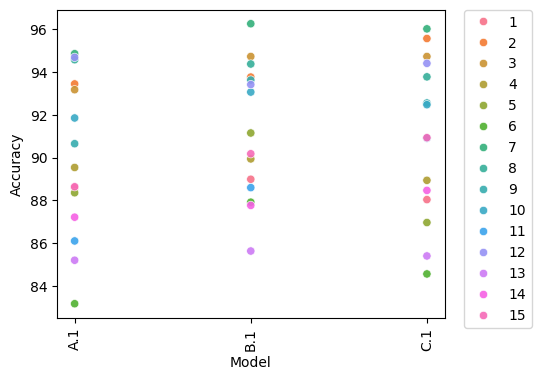

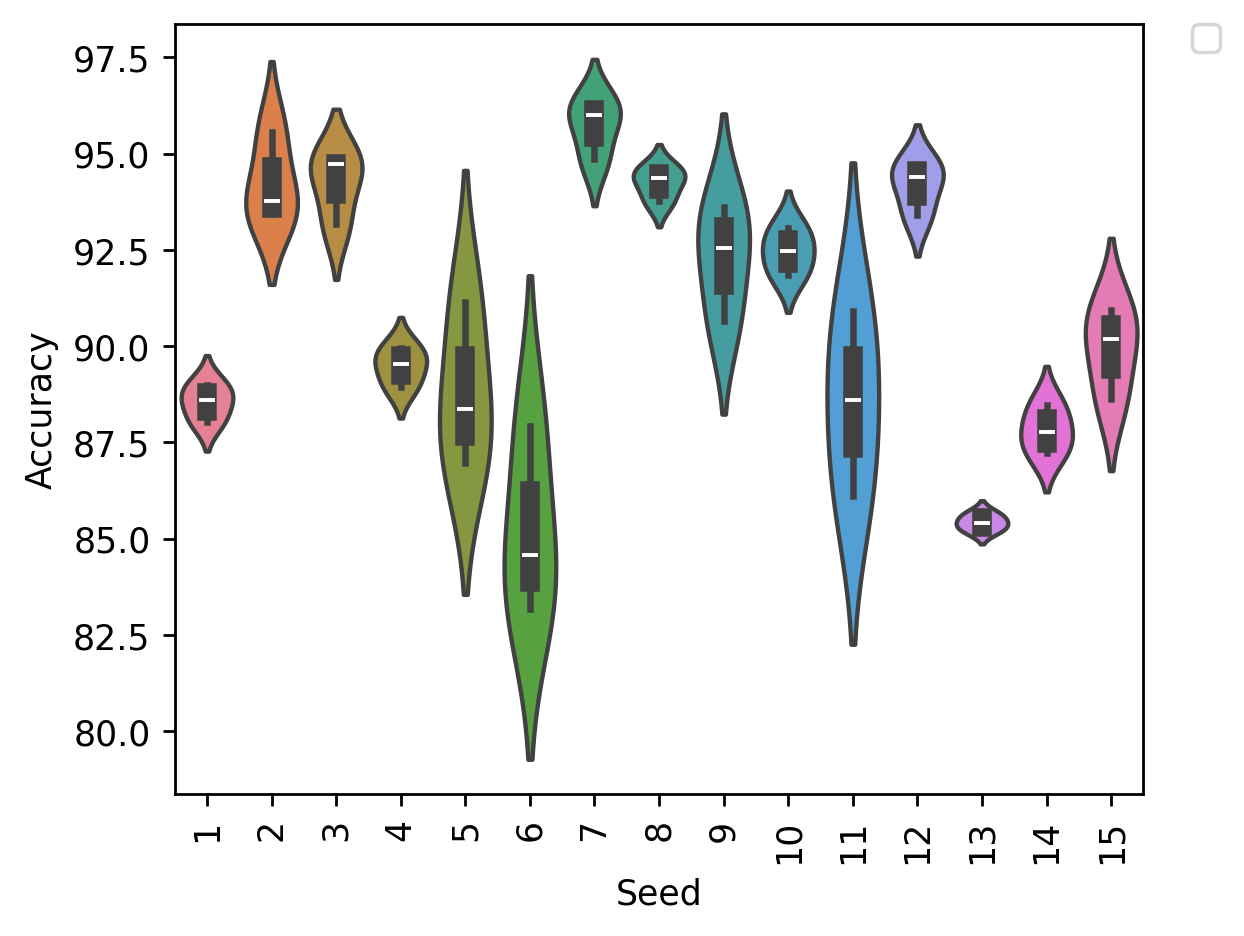

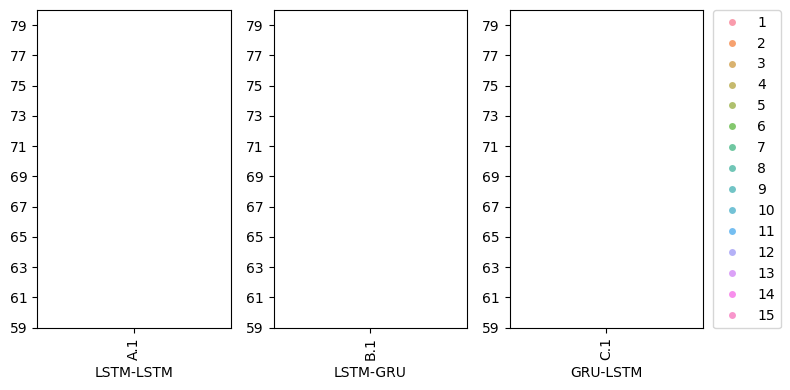

In [ ]:
from scipy import stats

#
# Remove trials starting with B
plot_trials_long = plot_trials_long

plt.figure(figsize=(5, 4))
sns.scatterplot(data=plot_trials_long, x="ModelName", y="Accuracy", hue="Seed", alpha=0.9)
plt.xticks(rotation=90)
plt.xlabel("Model")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

plt.figure(figsize=(5, 4), dpi=250)
sns.violinplot(data=plot_trials_long.query("Seed!='Mean'"), x="Seed", y="Accuracy", hue="Seed")
plt.xticks(rotation=90)
plt.xlabel("Seed")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

query1 = "ModelName.str.contains('.1')"
query2 = "ModelName.str.contains('.2')"
# Query model name contains letter "A"
queryA = "ModelName.str.contains('A.')"
queryB = "ModelName.str.contains('B.')"
queryC = "ModelName.str.contains('C.')"

# String does not contain .1
querynot1 = "ModelName.str.contains('.1')==False"


fig, axs = plt.subplots(figsize=(8, 4), width_ratios=[1,1,1],nrows=1, ncols=3)
#sns.boxplot(data=plot_trials_long.query(query1  + " or " + query2), x="ModelName", y="Accuracy", ax=axs[0], color="white")
#sns.stripplot(data=plot_trials_long.query(query1  + " or " + query2), x="ModelName", y="Accuracy", ax=axs[0], hue="Seed", alpha=0.7)
#axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=90)
#axs[0].get_legend().remove()
#axs[0].set_xlabel("Kernel-Size")
#axs[0].set_ylim(82,98)
#axs[0].set_yticks(np.arange(82, 99, 2))

sns.boxplot(data=plot_trials_long.query(queryA), x="ModelName", y="Accuracy", ax=axs[0], color="white")
sns.stripplot(data=plot_trials_long.query(queryA), x="ModelName", y="Accuracy", ax=axs[0],hue="Seed", alpha=0.7)
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=90)
axs[0].set_xlabel("LSTM-LSTM")
axs[0].get_legend().remove()
axs[0].set_ylabel("")
axs[0].set_ylim(59,80)
axs[0].set_yticks(np.arange(59, 80, 2))

sns.boxplot(data=plot_trials_long.query(queryB), x="ModelName", y="Accuracy", ax=axs[1], color="white")
sns.stripplot(data=plot_trials_long.query(queryB), x="ModelName", y="Accuracy", ax=axs[1], hue="Seed", alpha=0.7)
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=90)
axs[1].set_xlabel("LSTM-GRU")
axs[1].get_legend().remove()
axs[1].set_ylabel("")
axs[1].set_ylim(59,80)
axs[1].set_yticks(np.arange(59, 80, 2))

sns.boxplot(data=plot_trials_long.query(queryC), x="ModelName", y="Accuracy", ax=axs[2], color="white")
sns.stripplot(data=plot_trials_long.query(queryC ), x="ModelName", y="Accuracy", ax=axs[2], hue="Seed", alpha=0.7)
axs[2].set_xticklabels(axs[2].get_xticklabels(), rotation=90)
axs[2].set_xlabel("GRU-LSTM")
axs[2].legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
axs[2].set_ylabel("")
axs[2].set_ylim(59,80)
axs[2].set_yticks(np.arange(59, 80, 2))
plt.tight_layout()
plt.show()

/tmp/ipython-input-4023842682.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels(axs.get_xticklabels(), rotation=90)


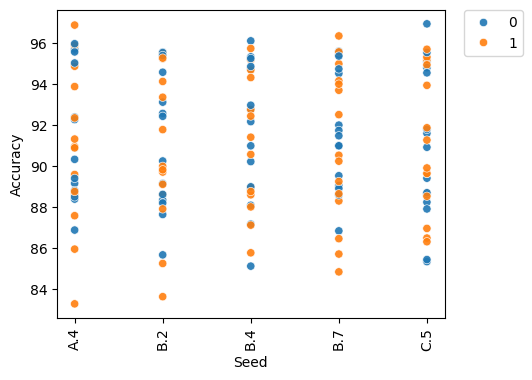

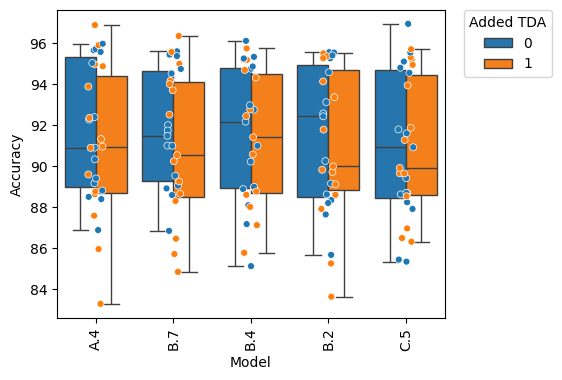

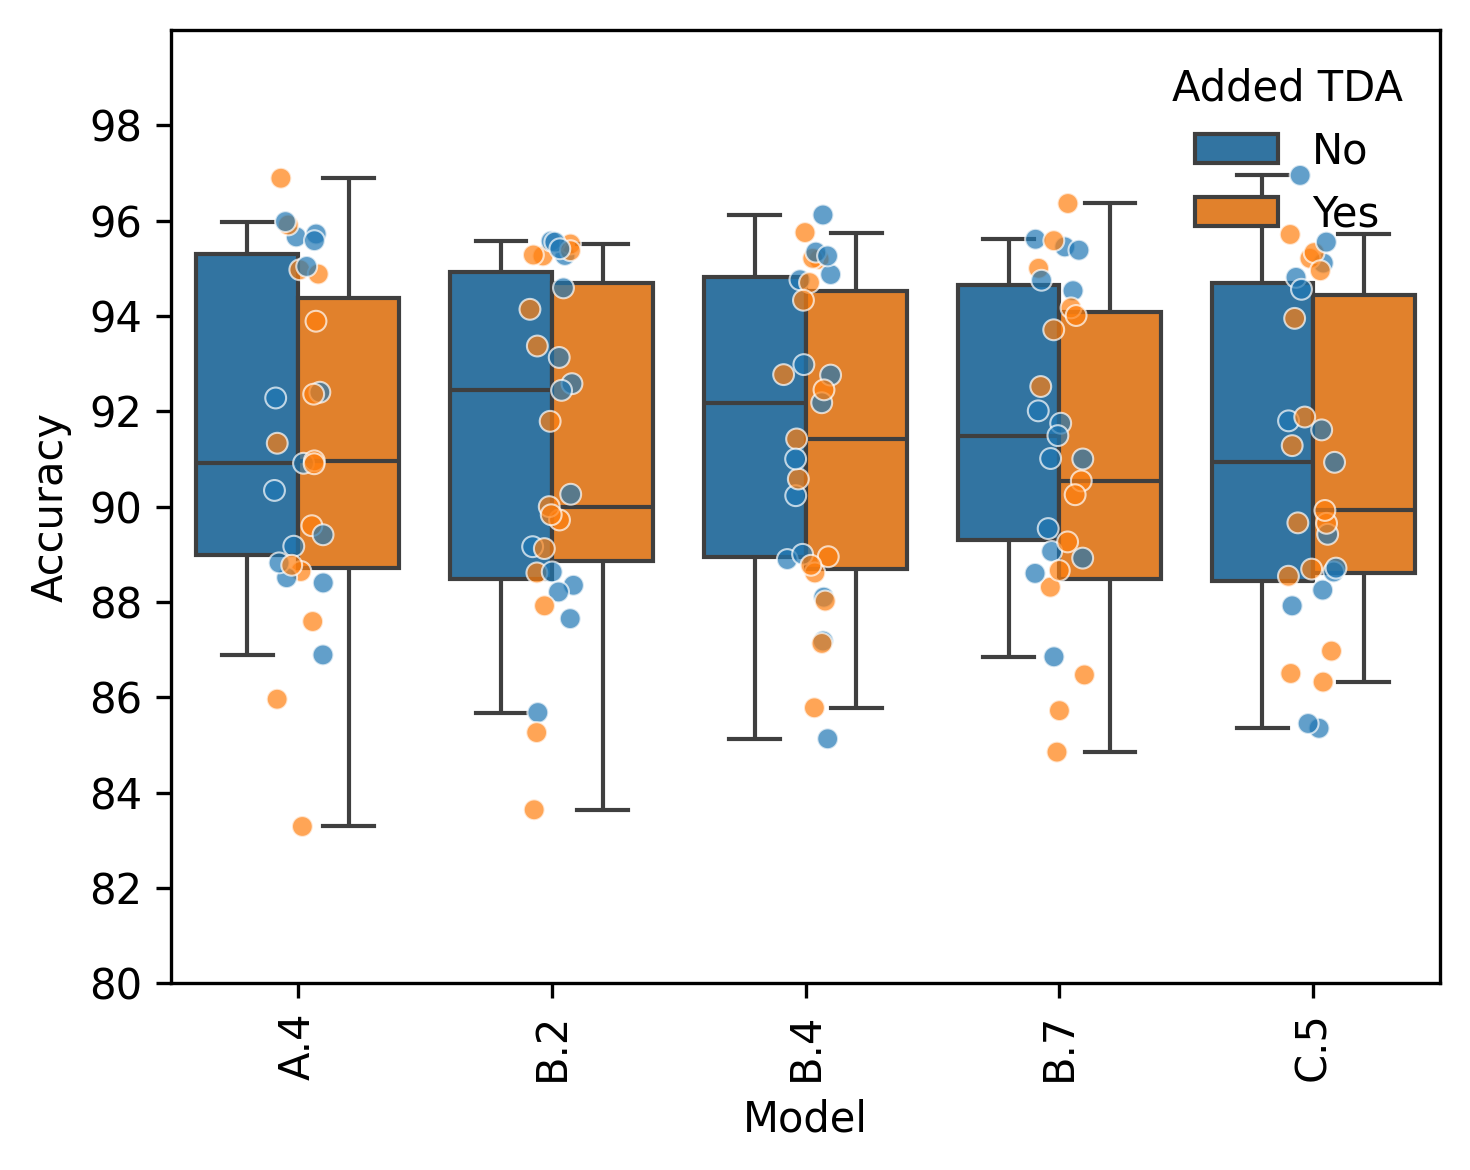

In [ ]:
from scipy import stats

plt.figure(figsize=(5, 4))
sns.scatterplot(data=plot_trials_long, x="ModelName", y="Accuracy", hue="TDA", alpha=0.9)
plt.xticks(rotation=90)
plt.xlabel("Seed")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

plt.figure(figsize=(5, 4))
sns.boxplot(data=plot_trials_long.sort_values('TDA'),x="ModelName", y="Accuracy", hue="TDA", saturation=0.9)
sns.stripplot(data=plot_trials_long,x="ModelName", y="Accuracy", hue="TDA", edgecolor='white', linewidth=0.5, legend=False)
plt.xticks(rotation=90)
plt.xlabel("Model")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title="Added TDA")

query1 = "ModelName.str.contains('.1')"
query2 = "ModelName.str.contains('.2')"
# Query model name contains letter "A"
queryA = "ModelName.str.contains('A.')"
queryB = "ModelName.str.contains('B.')"
queryC = "ModelName.str.contains('C.')"

# String does not contain .1
querynot1 = "ModelName.str.contains('.1')==False"


fig, axs = plt.subplots(figsize=(5,4), width_ratios=[1],nrows=1, ncols=1, dpi=300)
#
sns.boxplot(data=plot_trials_long, x="ModelName", y="Accuracy", ax=axs, hue="TDA")
sns.stripplot(data=plot_trials_long, x="ModelName", y="Accuracy", ax=axs,
              hue ='TDA', hue_order=['0','1'],alpha=0.7, edgecolor='white',linewidth=0.5)

axs.set_xticklabels(axs.get_xticklabels(), rotation=90)
axs.get_legend().remove()
axs.set_xlabel("Model")
axs.set_ylim(80,100)
axs.set_yticks(np.arange(80,100, 2))
# Relabel legend entries: 0 → No, 1 → Yes
handles, labels = axs.get_legend_handles_labels()
label_map = {
    "0": "No",
    "1": "Yes"
}
labels = [label_map.get(l, l) for l in labels]

axs.legend(
    handles[:2], labels[:2],
    title="Added TDA",
    #bbox_to_anchor=(0.99, 1.01),
    loc="upper right",
    frameon=False
)

plt.tight_layout()
plt.show()




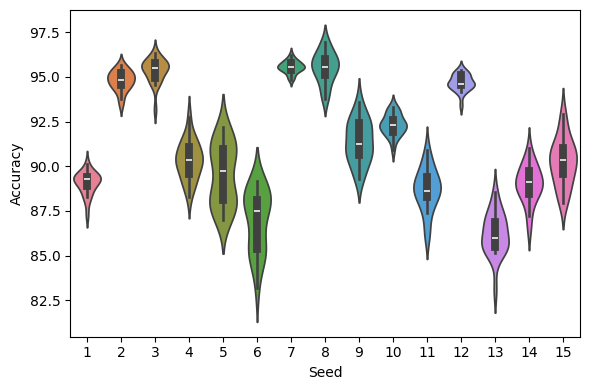

In [ ]:
import itertools
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

plt.figure(figsize=(6, 4))

sns.violinplot(
    data=plot_trials_long.query("Seed!='Mean'"),
    x="Seed", y="Accuracy", hue="Seed", dodge=False
)

plt.tight_layout()
plt.show()


## Table : Generate class balance table for WISDM6 seeds

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

wisdm_data = pd.read_csv('/content/drive/MyDrive/WISDM_Data/WISDM_ar_v1.1_raw_clean.csv')

#logger.info("Splitting the data by participants...")
participants = wisdm_data['user'].unique()


seeds1_4 = 5099, 17442, 1336, 91021
seeds5_11 =  2671, 89172, 23619, 5667, 120, 214, 9899
#for id in seeds5_11:

df = pd.DataFrame(columns=["seed", "test_users", "train_class_balance", "test_class_balance"])

for id in [5099, 17442, 1336, 91021, 2671, 89172, 23619, 5667, 120, 214, 9899]:

    #random_state_num = 5616
    random_state_num = id

    train_participants, test_participants = train_test_split(participants, test_size=0.2, random_state=random_state_num)
    train_data = wisdm_data[wisdm_data['user'].isin(train_participants)]
    test_data = wisdm_data[wisdm_data['user'].isin(test_participants)]
    # train class balance
    train_class_balance = train_data['activity'].value_counts()/sum(train_data['activity'].value_counts())
    test_class_balance = test_data['activity'].value_counts()/sum(test_data['activity'].value_counts())
    # Round to 3sf
    train_class_balance = train_class_balance.round(3)
    test_class_balance = test_class_balance.round(3)
    # Shorten labels
    train_class_balance.index = train_class_balance.index.str[:3]
    test_class_balance.index = test_class_balance.index.str[:3]
    # add index
    train_class_balance = train_class_balance.reset_index()
    test_class_balance = test_class_balance.reset_index()




    #Put each list into into a column in a dataframe
    df = pd.concat([df, pd.DataFrame({"seed": [id],
                                      #"train_users": [train_participants],
                                      "test_users": [test_participants],
                                      "train_class_balance":[train_class_balance.values],
                                      "test_class_balance":[test_class_balance.values]})])



    print("Train:", train_participants)
    print("Test:", test_participants)
print(df)
df.to_csv("seeds.csv")

# Convert to LaTeX table
latex_table = df.to_latex(index=False)
print(latex_table)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: [ 6 35 20  9 14  3  8 17 15 36 29 23 32 34  4 31 16 21  5 24 19  2 33 28
 12 26  1  7]
Test: [25 13 27 11 10 22 18 30]
Train: [25 36 35  6 28 16 15 32 27 18 13  2  1 11 21  7 34 12 23 19  5 24 29  8
 17 30  4 26]
Test: [33  9 14 20 10  3 31 22]
Train: [25 23 14 28  8 20 31 18  5  7  6 12  4 17 29 13  2 24 11 33  1 30 16 36
  9 26  3 22]
Test: [10 15 19 21 35 32 34 27]
Train: [25 13  8 19 27 33  4  3 24 17 28  1 36 14 26 35 34  9 15 23 18 20 32  2
 11 12 22 21]
Test: [16 30  6 10  5  7 31 29]
Train: [29 24  6 25 32 22  1 18 35  8 13 19  3 16 17 34  5  9 27 33  2 21 15 12
 14 31 36  7]
Test: [11 26  4 20 10 30 23 28]
Train: [ 1 15  2  6 25 24  9 28 14 10 21 29 18 17  8  7 34 13 31 33 32  5 23 27
  4  3 26 20]
Test: [35 22 11 30 19 16 12 36]
Train: [12  3 32 31 26 25 19 20  9 16 11 14 22 35  5 23  4 24 36 17 21  1  7 15
  2 29 30 27]
Test: [18 10 34 33 28

In [ ]:

test_class_balance
# remove "activity" column heading from test_class_balance
#test_class_balance = test_class_balance.rename(columns={"index": "activity"})
# remove header, just print values
print(test_class_balance.to_string(index=False))
for i in range(len(test_class_balance)):
    print(test_class_balance.iloc[i,2], test_class_balance.iloc[i,3])


activity activity activity  count
       0        0      Wal  0.397
       1        1      Jog  0.321
       2        2      Ups  0.102
       3        3      Dow  0.086
       4        4      Sta  0.053
       5        5      Sit  0.040
Wal 0.397
Jog 0.321
Ups 0.102
Dow 0.086
Sta 0.053
Sit 0.04
